# U-neXt Plots 

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from tensorboard.backend.event_processing.event_accumulator import EventAccumulator

# path to lightning log folder
log_dir = "../../out/lightning_logs/version_2"

# load event files
event_acc = EventAccumulator(log_dir)
event_acc.Reload()

# available metrics
print("Available tags:", event_acc.Tags()["scalars"])

# extract values
def extract_metric(metric_name):
    if metric_name not in event_acc.Tags()["scalars"]:
        print(f"{metric_name} not found!")
        return None, None
    
    events = event_acc.Scalars(metric_name)
    epochs = np.arange(len(events))  
    values = [e.value for e in events]
    return epochs, np.array(values)

# extract metrics
train_loss_steps, train_loss = extract_metric("train_avg_loss")
epochs_val_loss, val_loss = extract_metric("val_avg_loss")

#train_iou_steps, train_iou = extract_metric("train_mean_iou", True)
val_iou_steps, val_iou = extract_metric("val_mean_iou")

Available tags: ['hp_metric', 'val_avg_loss', 'val_mean_iou', 'val_iou_0', 'val_iou_1', 'val_iou_2', 'val_iou_3', 'val_iou_4', 'val_iou_5', 'val_iou_6', 'epoch', 'train_avg_loss', 'train_iou_0', 'train_iou_1', 'train_iou_2', 'train_iou_3', 'train_iou_4', 'train_iou_5', 'train_iou_6', 'test_avg_loss', 'test_iou_0', 'test_iou_1', 'test_iou_2', 'test_iou_3', 'test_iou_4', 'test_iou_5', 'test_iou_6']


In [2]:
# extract values
def extract_metric(metric_name):
    if metric_name not in event_acc.Tags()["scalars"]:
        print(f"{metric_name} not found!")
        return None, None
    
    events = event_acc.Scalars(metric_name)
    epochs = np.arange(len(events))  
    values = [e.value for e in events]
    return epochs, np.array(values)

def plot_loss(log_dir):

    # load event files
    event_acc = EventAccumulator(log_dir)
    event_acc.Reload()

    # extract metrics
    train_loss_steps, train_loss = extract_metric("train_avg_loss")
    epochs_val_loss, val_loss = extract_metric("val_avg_loss")

    train_events = event_acc.Scalars("train_avg_loss")
    train_steps = np.array([e.step for e in train_events])
    train_values = np.array([e.value for e in train_events])

    # estimate steps per epoch
    num_epochs = len(val_loss)  # from validation 
    steps_per_epoch = len(train_values) // num_epochs

    train_loss_epoch = train_values.reshape(num_epochs, steps_per_epoch).mean(axis=1)
    epochs_train = np.arange(num_epochs)

    plt.figure()
    plt.plot(epochs_train, train_loss_epoch)
    plt.plot(epochs_val_loss, val_loss)
    plt.ylim(0, 0.0225)
    plt.xlabel("Epoch", fontsize=14)
    plt.ylabel("Loss", fontsize=14)
    plt.title("Train vs Validation Loss", fontsize=16)
    plt.legend(["Train Loss", "Validation Loss"])
    plt.show()

    return event_acc


def plot_iou(event_acc):

    num_classes = 7

    train_class_ious = []

    for c in range(num_classes):
        events = event_acc.Scalars(f"train_iou_{c}")
        values = [e.value for e in events]
        train_class_ious.append(values)

    train_class_ious = np.array(train_class_ious)

    train_mean_iou = np.nanmean(train_class_ious, axis=0)
    epochs = np.arange(len(train_mean_iou))

    val_events = event_acc.Scalars("val_mean_iou")
    val_mean_iou = np.array([e.value for e in val_events])

    plt.figure()
    plt.plot(epochs, train_mean_iou)
    plt.plot(epochs, val_mean_iou)

    plt.xlabel("Epoch", fontsize=14)
    plt.ylabel("Mean IoU", fontsize=14)
    plt.title("Train vs Validation Mean IoU", fontsize=16)
    plt.legend(["Train Mean IoU", "Validation Mean IoU"])
    plt.show()

#### no augmentation, no dropouts

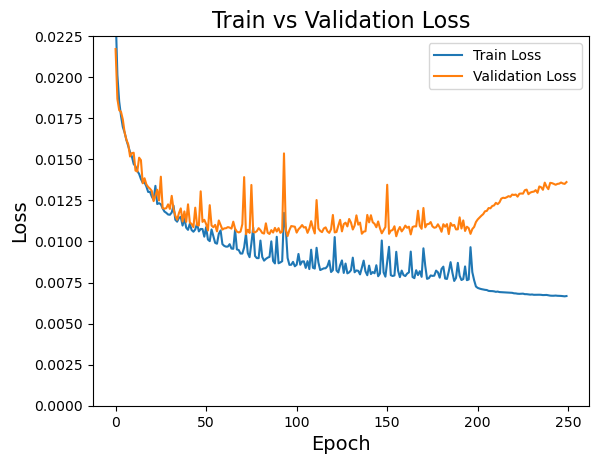

In [28]:
event_acc = plot_loss("../../out/lightning_logs/version_2")

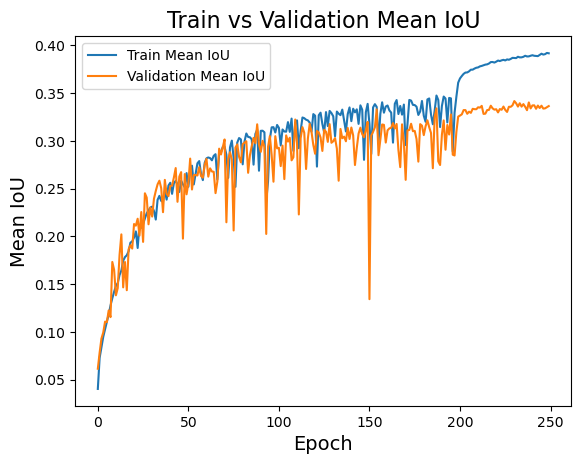

In [10]:
plot_iou(event_acc)

#### no augmentation +dropouts   --log-interval 5 --epochs 250 --weight-decay 0.00001 --dropout-val 0.1 --lr 0.003 --training-batch-size 8 --test-batch-size 8 

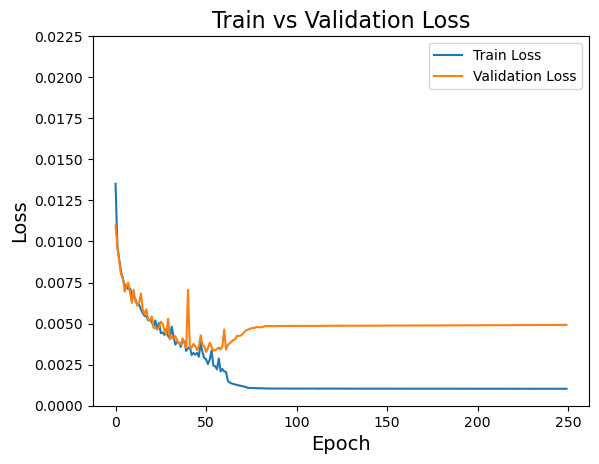

In [31]:
event_acc = plot_loss("../../out/lightning_logs/version_19")

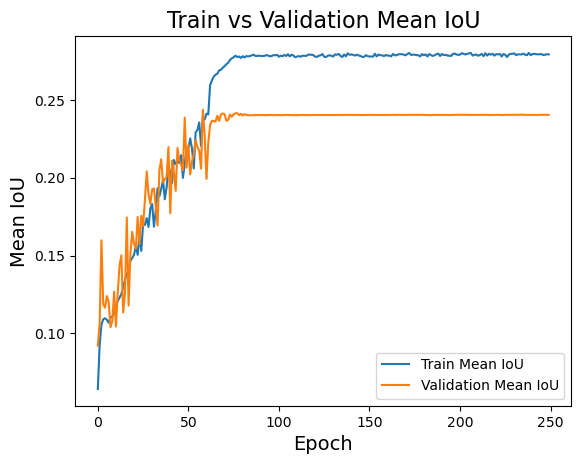

In [32]:
plot_iou(event_acc)

#### flip & rotation + dropouts --log-interval 5 --epochs 250 --weight-decay 0.00001 --dropout-val 0.1 --lr 0.003 --training-batch-size 8 --test-batch-size 8

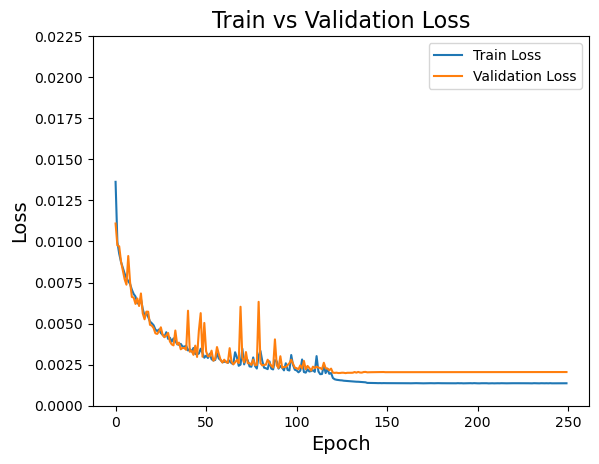

In [5]:
event_acc = plot_loss("../../out/lightning_logs/version_20")

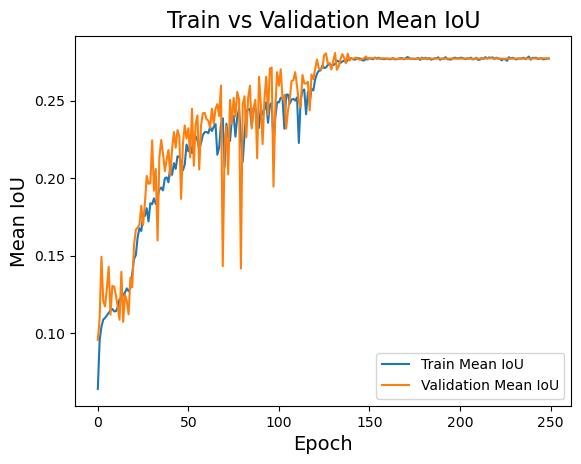

In [7]:
plot_iou(event_acc)

#### flip+rotation+brightness+gaussnoise + dropouts --log-interval 5 --epochs 250 --weight-decay 0.00001 --dropout-val 0.1 --lr 0.003 --training-batch-size 8 --test-batch-size 8

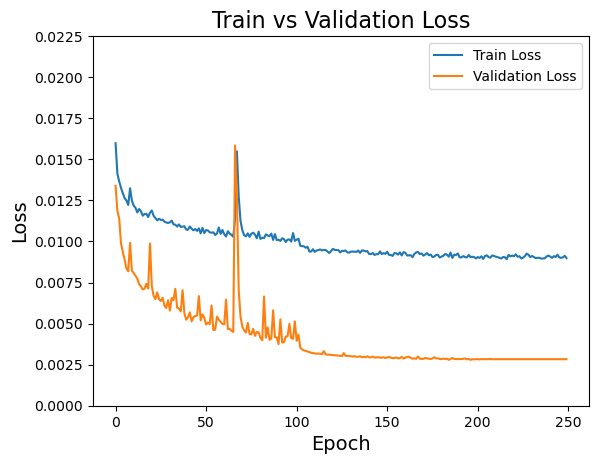

In [5]:
event_acc = plot_loss("../../out/lightning_logs/version_21")

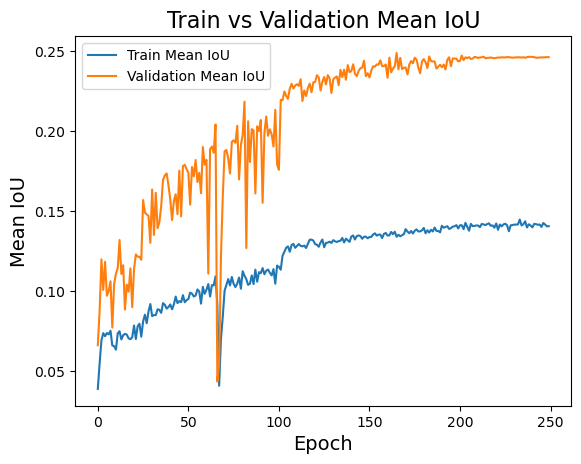

In [7]:
plot_iou(event_acc)

(1, 7, 256, 256)
[4.3810479e-04 4.4204816e-04 4.5257778e-04 ... 9.9775523e-01 9.9792743e-01
 9.9814534e-01]


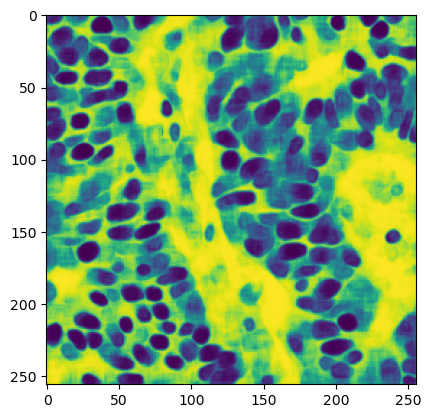

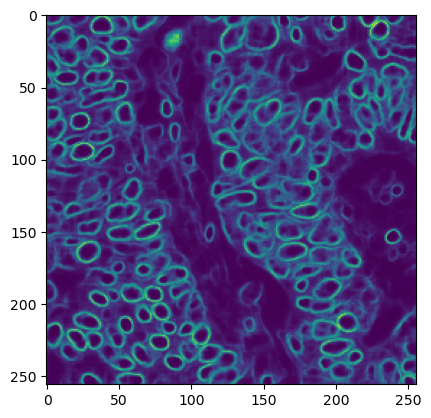

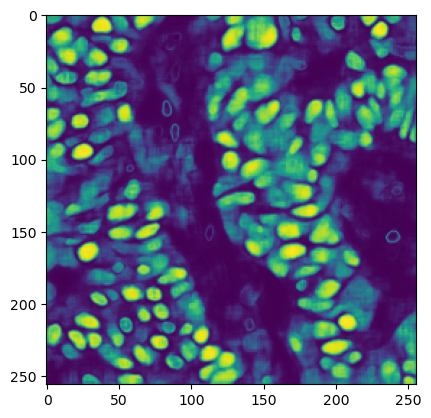

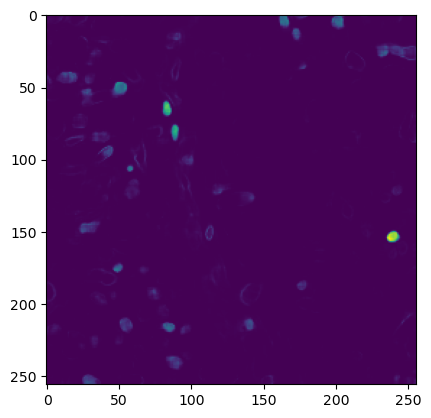

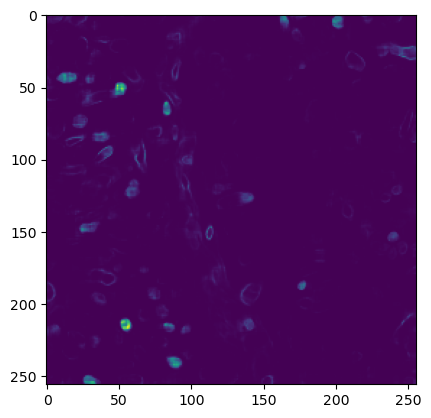

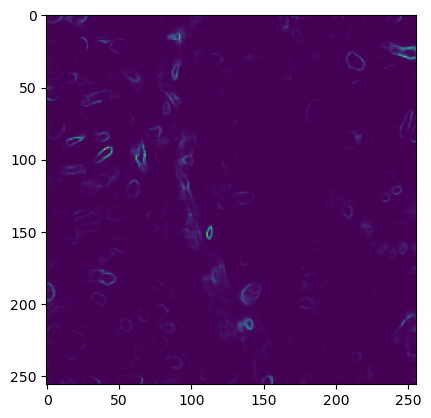

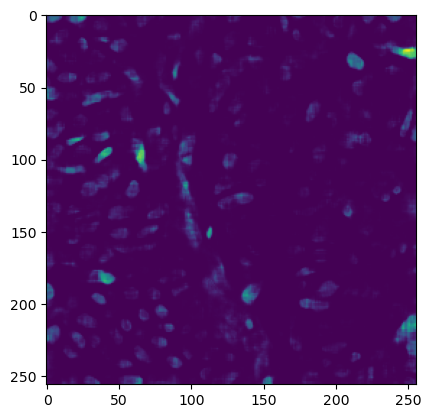

(4, 256, 256)
[0. 1. 2. 3. 4. 5. 6.]


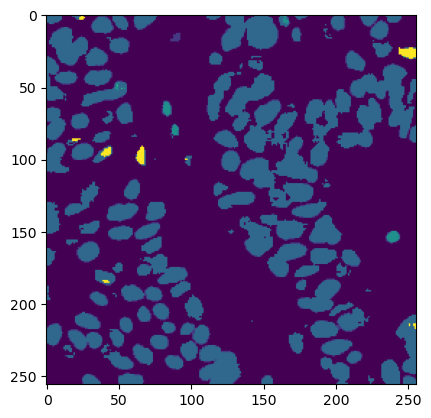

In [32]:
unet = np.load("../../../CRC-HnE-Segmentation-Prediction/out/unet.npy", allow_pickle=True)
print(unet.shape)
print(np.unique(unet[0, 0]))

import matplotlib.pyplot as plt
plt.imshow(unet[0, 0]) 
plt.show()
plt.imshow(unet[0, 1])
plt.show()
plt.imshow(unet[0, 2])
plt.show()
plt.imshow(unet[0, 3])
plt.show()
plt.imshow(unet[0, 4])
plt.show()
plt.imshow(unet[0, 5])
plt.show()      
plt.imshow(unet[0, 6])
plt.show()


from tifffile import imread
image = imread("../../../CRC-HnE-Segmentation-Prediction/consep_1-0000.ome.tif")
print(image.shape)
print(np.unique(image[3,:,:]))
plt.imshow(image.transpose(1, 2, 0)[:,:,3])
plt.show()